# 01. Baseline Design and Model Selection

baseline을 어떻게 설계하고, 여러 모델 중 무엇을 우선 비교 대상으로 둘까?

**목표**
1. 왜 baseline이 필요한지 이해한다.
2. 분류 문제에서 train / validation / test를 어떻게 나누는지 확인한다.
3. 머신러닝 모델과 딥러닝 MLP baseline을 같은 기준으로 비교한다.
4. test를 먼저 보지 않고 validation 결과를 기준으로 후보를 고르는 흐름을 연습한다.

**주의할 점**
- 최종 최고 성능보다 비교 가능한 출발점 만들기에 초점을 둔다.
- 아주 복잡한 튜닝보다, 여러 모델을 공정한 기준으로 먼저 비교하는 흐름이 더 중요하다.
- 프로젝트에서도 처음부터 한 모델에 과몰입하기보다 baseline을 여러 개 두고 출발하는 편이 안정적이다.

## 1. Baseline이 왜 필요한가

특정 task에 대해서 **딥러닝이 더 좋아 보이니까 MLP부터 하자** 또는 **트리 모델이 잘 나온다던데 그걸 쓰자** 같은 식으로 접근하기 쉽다.

하지만 이렇게 시작하면 아래 문제가 생긴다.

1. 지금 모델이 정말 괜찮은지 비교 기준이 없다.
2. 데이터에 비해 모델이 과한지, 부족한지 판단이 어렵다.
3. 성능이 안 나왔을 때 무엇을 바꿔야 하는지 기준이 흐려진다.

그래서 baseline이 필요하다.

baseline은 현재 데이터에서 최소한 이 정도는 나와야 한다 
또는 여러 후보 중 어떤 방향이 더 유리한지 비교하기 위한 출발점 역할을 한다.

- 아주 단순한 기준 모델(DummyClassifier)
- 대표적인 머신러닝 모델들
- 간단한 MLP baseline
- validation 성능 기준으로 1차 후보 선택
- 마지막에 test는 딱 한 번 확인

## 2. 실습 데이터

`make_classification()`으로 생성한 tabular 이진 분류 데이터를 사용한다.

이 데이터는 아래 특징을 가지도록 만든다.

- sample 수가 아주 적지 않다.
- informative feature와 noise feature가 섞여 있다.
- class imbalance가 어느 정도 있다.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# 재현 가능성을 위한 seed 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## 3. 데이터 생성

분류 데이터는 `make_classification()`으로 만든다.

- `n_samples`: 전체 샘플 수
- `n_features`: 전체 feature 수
- `n_informative`: 실제로 class 구분에 도움이 되는 feature 수
- `n_redundant`: informative feature의 조합으로 만들어지는 중복 feature 수
- `weights`: 클래스 비율
- `flip_y`: 일부 라벨에 noise를 섞는 비율

즉, 완전히 깨끗한 데이터가 아니라 약간의 현실적인 난이도를 가진 데이터라고 보면 된다.

In [2]:
# 이진 분류용 tabular 데이터 생성
X, y = make_classification(
    n_samples=12000,          # 샘플 수
    n_features=30,            # 전체 feature 수
    n_informative=10,         # 실제로 도움이 되는 feature 수
    n_redundant=6,            # informative feature 조합으로 만든 중복 feature
    n_repeated=0,             # 반복 feature 수
    n_classes=2,              # 이진 분류
    n_clusters_per_class=2,   # 클래스별 cluster 수
    weights=[0.72, 0.28],     # 약간의 클래스 불균형
    flip_y=0.04,              # 라벨 노이즈
    class_sep=0.9,            # 클래스 분리 정도
    random_state=SEED
)

feature_names = [f'feature_{i:02d}' for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print('shape:', df.shape)
print(df.head())

shape: (12000, 31)
   feature_00  feature_01  feature_02  feature_03  feature_04  feature_05  \
0    1.358374    3.584573   -2.052339   -7.418526   -0.478628   -1.349334   
1   -0.487225   -0.802246   -1.014614    6.265392    1.553449    8.012887   
2   -1.516402   -0.722782    1.262809    3.514417    0.816030    8.781202   
3    0.145712   -1.512005    2.172018   -6.164856   -1.242872   -5.558634   
4    0.609857    0.126410    0.163365    2.323290    0.617478   -3.004455   

   feature_06  feature_07  feature_08  feature_09  ...  feature_21  \
0   -0.061837    0.903008    0.750935   -0.049824  ...    1.511704   
1    0.932700   -0.330280    0.282922   -0.769743  ...   -2.329832   
2   -0.821640   -0.735248   -0.419626   -1.903751  ...    5.686515   
3    2.309538   -1.351000   -1.088102    1.092160  ...   -2.972386   
4   -1.654487    0.285974    0.071870   -1.608190  ...   -0.611299   

   feature_22  feature_23  feature_24  feature_25  feature_26  feature_27  \
0    1.868044    0.2

target
0    0.710167
1    0.289833
Name: proportion, dtype: float64


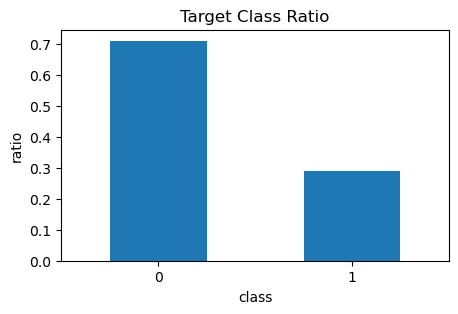

In [3]:
# 타깃 분포 확인
target_ratio = df['target'].value_counts(normalize=True).sort_index()
print(target_ratio)

plt.figure(figsize=(5, 3))
target_ratio.plot(kind='bar')
plt.title('Target Class Ratio')
plt.xlabel('class')
plt.ylabel('ratio')
plt.xticks(rotation=0)
plt.show()

## 4. train / validation / test 분리

- train: 모델 학습
- validation: 모델 선택, 하이퍼파라미터 비교
- test: 최종 1회 평가

test를 중간중간 계속 보면 사실상 test에 맞춰 의사결정을 하게 되므로 공정한 최종 평가가 어려워진다.

여기서는 stratify를 사용해서 분할 뒤에도 클래스 비율이 크게 흔들리지 않도록 한다.

In [4]:
# 먼저 train+validation 과 test로 분리
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

# train+validation에서 다시 train / validation 분리
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,   # 전체 기준으로는 0.2
    stratify=y_train_val,
    random_state=SEED
)

print('X_train shape:', X_train.shape)
print('X_val shape  :', X_val.shape)
print('X_test shape :', X_test.shape)

print()
print('train class ratio:', np.bincount(y_train) / len(y_train))
print('val class ratio  :', np.bincount(y_val) / len(y_val))
print('test class ratio :', np.bincount(y_test) / len(y_test))

X_train shape: (7200, 30)
X_val shape  : (2400, 30)
X_test shape : (2400, 30)

train class ratio: [0.71013889 0.28986111]
val class ratio  : [0.71041667 0.28958333]
test class ratio : [0.71 0.29]


## 5. 어떤 metric으로 비교할 것인가

이진 분류에서는 정확도(accuracy)만 보면 위험한 경우가 있다.

예를 들어 불균형 데이터에서
전체의 72%가 0 클래스라면,
무조건 0만 예측해도 accuracy는 어느 정도 나올 수 있다.

그래서 비교에서는 아래 지표들을 함께 본다.

- accuracy: 전체적으로 맞춘 비율
- precision: 1이라고 예측한 것 중 실제 1의 비율
- recall: 실제 1 중에서 찾아낸 비율
- f1: precision과 recall의 균형
- roc_auc: threshold 전반에서 분리 능력
- average_precision(AP): positive class를 얼마나 상위 점수 구간에 잘 배치하는지를 보는 지표
  
AP는 precision-recall(PR) curve를 기반으로 계산되는 값이다.
직관적으로는 모델이 positive 샘플을 점수가 높은 쪽에 얼마나 잘 몰아놓았는가를 본다고 이해하면 된다.
이 지표가 유용한 이유는 threshold를 0.5처럼 하나로 고정해서 보는 것이 아니라, threshold를 여러 값으로 바꿔가며 precision과 recall의 변화를 함께 반영하기 때문이다.

여기서는 validation 기준의 1차 선택 지표를 `average_precision`으로 둔다.

1. 클래스 불균형이 조금 있다.
2. positive class를 얼마나 잘 상위로 끌어올리는지 보고 싶다.
3. threshold를 아직 고정하지 않은 상태에서 순위 기반 비교가 가능하다.

프로젝트에서는 비즈니스 목적에 따라 recall 우선, precision 우선, F1 우선 등으로 바꿀 수 있다.

In [5]:
def get_pred_and_score(model, X):
    '''
    모델별로 예측 라벨(pred)과 점수(score)를 통일해서 꺼내기 위한 함수이다.

    - pred: 최종 예측 클래스
    - score: positive class(1)에 대한 점수
      * predict_proba가 있으면 class 1 확률 사용
      * decision_function이 있으면 그 점수 사용
      * 둘 다 없으면 pred 자체를 점수처럼 대신 사용
    '''
    pred = model.predict(X)

    if hasattr(model, 'predict_proba'):
        score = model.predict_proba(X)[:, 1]
    elif hasattr(model, 'decision_function'):
        score = model.decision_function(X)
    else:
        score = pred.astype(float)

    return pred, score


def evaluate_classifier(model, X, y_true):
    '''
    분류 모델의 여러 평가 지표를 한 번에 계산하는 함수이다.
    '''
    pred, score = get_pred_and_score(model, X)

    result = {
        'accuracy': accuracy_score(y_true, pred),
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall': recall_score(y_true, pred, zero_division=0),
        'f1': f1_score(y_true, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, score),
        'average_precision': average_precision_score(y_true, score),
    }
    return result

## 6. 머신러닝 baseline 후보 만들기

대표적인 baseline 후보를 몇 개 준비한다.

1. DummyClassifier
   - 아무 학습이라기보다 최소 비교 기준 역할
2. LogisticRegression
   - 선형 baseline
3. KNeighborsClassifier
   - 거리 기반 baseline
4. SVC
   - decision boundary를 비선형으로 잡을 수 있는 kernel 기반 모델
5. RandomForestClassifier
   - 트리 앙상블 baseline
6. HistGradientBoostingClassifier
   - 부스팅 계열 baseline

중요한 점은 좋은 모델 몇 개를 외우는 것이 아니라,
데이터 특성에 따라 어떤 계열이 유리한지 감을 잡는 것이다.

In [6]:
# 모델 정의
# 스케일에 민감한 모델은 StandardScaler를 포함한 Pipeline으로 묶는다.
ml_models = {
    # train 데이터에서 가장 많이 나온 클래스를 보고, 예측할 때도 무조건 그 클래스만 찍는다.
    'dummy_most_frequent': DummyClassifier(strategy='most_frequent'),

    'logistic_regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, random_state=SEED))
    ]),

    'knn': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=15))
    ]),

    'svc_rbf': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', probability=True, random_state=SEED))
    ]),

    'random_forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1
    ),

    'hist_gradient_boosting': HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_depth=6,
        max_iter=300,
        random_state=SEED
    ),
}

In [7]:
# 각 머신러닝 모델 학습 및 validation 평가
ml_val_results = []

for model_name, model in ml_models.items():
    # train 데이터로 학습
    model.fit(X_train, y_train)

    # validation 성능 평가
    val_metrics = evaluate_classifier(model, X_val, y_val)

    # 결과 딕셔너리에 모델 이름 추가
    val_metrics['model'] = model_name
    ml_val_results.append(val_metrics)

ml_val_df = pd.DataFrame(ml_val_results)
ml_val_df = ml_val_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']]
ml_val_df = ml_val_df.sort_values(by='average_precision', ascending=False).reset_index(drop=True)

ml_val_df

c:\Users\Playdata\AppData\Local\miniforge3\envs\ai_basic_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,hist_gradient_boosting,0.927917,0.942373,0.800000,0.865370,0.960781,0.934100
1,random_forest,0.912083,0.954887,0.730935,0.828036,0.956238,0.928732
2,svc_rbf,0.907917,0.948864,0.720863,0.819297,0.948852,0.923879
3,knn,0.863333,0.944310,0.561151,0.703971,0.923469,0.860150
4,logistic_regression,0.822500,0.780793,0.538129,0.637138,0.847115,0.741477
5,dummy_most_frequent,0.710417,0.000000,0.000000,0.000000,0.500000,0.289583


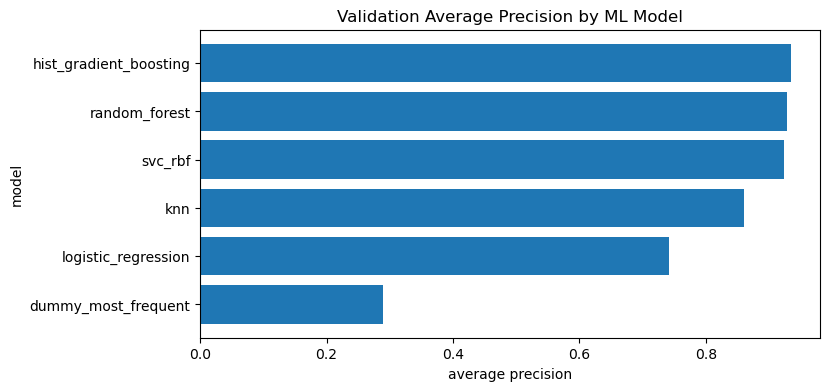

In [8]:
# validation 결과를 보기 좋게 시각화
plt.figure(figsize=(8, 4))
plt.barh(ml_val_df['model'], ml_val_df['average_precision'])
plt.gca().invert_yaxis()
plt.title('Validation Average Precision by ML Model')
plt.xlabel('average precision')
plt.ylabel('model')
plt.show()

## 7. 머신러닝 baseline 결과를 어떻게 읽을까

이 단계에서는 아직 test를 보지 않는다.

지금 확인하는 것은 현재 validation 기준으로 어느 계열이 더 유망해 보이는가이다.

- Dummy가 현저히 낮다면: 실제 학습이 의미 있게 되고 있다는 뜻이다.
- Logistic가 생각보다 괜찮다면: 선형 분리만으로도 어느 정도 설명 가능하다는 뜻이다.
- 트리 앙상블이 강하면: 비선형 관계나 feature interaction을 더 잘 잡고 있을 수 있다.
- KNN이 약하면: 현재 스케일링을 해도 거리 기반 접근이 덜 맞을 수 있다.

즉, 숫자 하나만 보는 것이 아니라 모델 계열별 특성과 함께 해석하는 연습이 중요하다.

## 8. MLP baseline 추가

표 데이터인데 MLP도 비교해야 하나? 딥러닝이니까 무조건 더 좋은가?

답은 데이터마다 다르다.

tabular 데이터에서는 전통적인 머신러닝 모델, 특히 트리 계열이 MLP보다 강한 경우도 많다.
그래서 더더욱 공정한 baseline 비교가 필요하다.

여기서는 아주 복잡한 딥러닝 구조가 아니라 표 데이터용 단순 MLP baseline을 만든다.

In [9]:
# MLP는 입력 스케일의 영향을 꽤 받으므로
# train 데이터 기준으로 scaler를 학습하고, validation / test에는 transform만 적용한다.
mlp_scaler = StandardScaler()

X_train_scaled = mlp_scaler.fit_transform(X_train)
X_val_scaled = mlp_scaler.transform(X_val)
X_test_scaled = mlp_scaler.transform(X_test)

print('scaled train shape:', X_train_scaled.shape)

scaled train shape: (7200, 30)


In [10]:
# numpy 배열을 PyTorch tensor로 변환한다.
# 분류 target은 BCEWithLogitsLoss를 쓰기 위해 float 형태와 (N, 1) shape로 맞춘다.
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [11]:
class TabularMLP(nn.Module):
    '''
    표 데이터용 간단한 MLP baseline이다.
    너무 복잡한 구조보다,
    baseline 비교용으로 무난한 2 hidden layer 구조를 사용한다.
    '''
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),

            nn.Linear(64, 1)   # 이진 분류 logit 출력
        )

    def forward(self, x):
        return self.net(x)

In [12]:
def get_binary_metrics_from_logits(y_true, logits, threshold=0.5):
    '''
    BCEWithLogitsLoss를 쓰는 경우 모델 출력은 확률이 아니라 logit이다.
    따라서 sigmoid를 통과시켜 확률로 바꾼 뒤 평가한다.
    '''
    probs = torch.sigmoid(logits).cpu().numpy().ravel()
    preds = (probs >= threshold).astype(int)
    y_true = y_true.cpu().numpy().ravel().astype(int)

    metrics = {
        'accuracy': accuracy_score(y_true, preds),
        'precision': precision_score(y_true, preds, zero_division=0),
        'recall': recall_score(y_true, preds, zero_division=0),
        'f1': f1_score(y_true, preds, zero_division=0),
        'roc_auc': roc_auc_score(y_true, probs),
        'average_precision': average_precision_score(y_true, probs),
    }
    return metrics, probs, preds


def evaluate_mlp(model, loader, criterion):
    '''
    validation / test에서 loss와 분류 지표를 계산한다.
    '''
    model.eval()

    total_loss = 0.0
    all_logits = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            all_logits.append(logits)
            all_targets.append(y_batch)

    avg_loss = total_loss / len(loader.dataset)
    logits = torch.cat(all_logits, dim=0)
    targets = torch.cat(all_targets, dim=0)

    metrics, probs, preds = get_binary_metrics_from_logits(targets, logits)
    metrics['loss'] = avg_loss
    return metrics, probs, preds

In [13]:
# 클래스 불균형을 약간 보정하기 위해 positive class 가중치를 계산한다.
# pos_weight = (negative 개수 / positive 개수) 정도로 두면,
# positive class를 놓쳤을 때의 손실이 조금 더 크게 반영된다.
num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()
pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32)

print('num_neg:', num_neg)
print('num_pos:', num_pos)
print('pos_weight:', pos_weight.item())

num_neg: 5113
num_pos: 2087
pos_weight: 2.449928045272827


In [14]:
# MLP baseline 학습
model = TabularMLP(input_dim=X_train.shape[1])

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 25

history = {
    'train_loss': [],
    'val_loss': [],
    'val_f1': [],
    'val_ap': [],
}

best_state = None
best_val_ap = -1.0
best_epoch = -1

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    val_metrics, _, _ = evaluate_mlp(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['val_f1'].append(val_metrics['f1'])
    history['val_ap'].append(val_metrics['average_precision'])

    # validation average precision 기준으로 best model 저장
    if val_metrics['average_precision'] > best_val_ap:
        best_val_ap = val_metrics['average_precision']
        best_epoch = epoch + 1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"epoch={epoch+1:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f} | "
        f"val_ap={val_metrics['average_precision']:.4f}"
    )

print()
print('best_epoch:', best_epoch)
print('best_val_ap:', round(best_val_ap, 4))

epoch=01 | train_loss=0.7425 | val_loss=0.5993 | val_f1=0.7197 | val_ap=0.8159
epoch=02 | train_loss=0.5755 | val_loss=0.4995 | val_f1=0.7906 | val_ap=0.8801
epoch=03 | train_loss=0.5061 | val_loss=0.4410 | val_f1=0.8167 | val_ap=0.9087
epoch=04 | train_loss=0.4522 | val_loss=0.4099 | val_f1=0.8282 | val_ap=0.9150
epoch=05 | train_loss=0.4318 | val_loss=0.3930 | val_f1=0.8500 | val_ap=0.9219
epoch=06 | train_loss=0.3966 | val_loss=0.3806 | val_f1=0.8450 | val_ap=0.9248
epoch=07 | train_loss=0.3913 | val_loss=0.3727 | val_f1=0.8438 | val_ap=0.9281
epoch=08 | train_loss=0.3675 | val_loss=0.3619 | val_f1=0.8550 | val_ap=0.9325
epoch=09 | train_loss=0.3660 | val_loss=0.3567 | val_f1=0.8667 | val_ap=0.9347
epoch=10 | train_loss=0.3595 | val_loss=0.3497 | val_f1=0.8645 | val_ap=0.9359
epoch=11 | train_loss=0.3461 | val_loss=0.3479 | val_f1=0.8609 | val_ap=0.9362
epoch=12 | train_loss=0.3264 | val_loss=0.3529 | val_f1=0.8682 | val_ap=0.9362
epoch=13 | train_loss=0.3166 | val_loss=0.3397 | val

In [15]:
# 가장 좋았던 validation 시점의 가중치를 다시 불러온다.
model.load_state_dict(best_state)

# best model 기준 validation 성능 재계산
mlp_val_metrics, mlp_val_probs, mlp_val_preds = evaluate_mlp(model, val_loader, criterion)
mlp_val_metrics

{'accuracy': 0.9279166666666666,
 'precision': 0.8604972375690608,
 'recall': 0.8964028776978418,
 'f1': 0.8780831571529246,
 'roc_auc': 0.9620869638599971,
 'average_precision': 0.9443267618616021,
 'loss': 0.332212328116099}

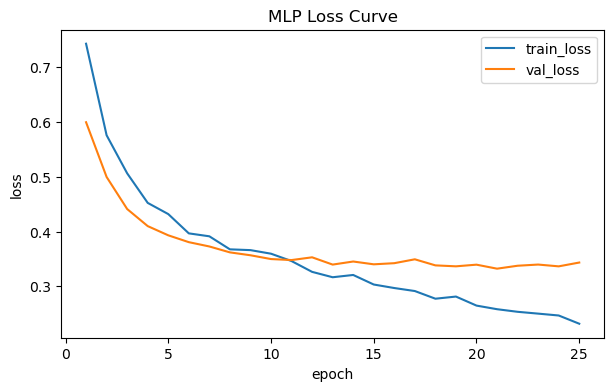

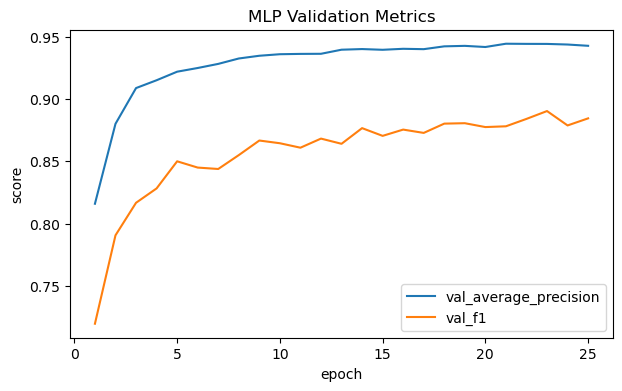

In [16]:
# 학습 곡선 확인
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs, history['train_loss'], label='train_loss')
plt.plot(epochs, history['val_loss'], label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('MLP Loss Curve')
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs, history['val_ap'], label='val_average_precision')
plt.plot(epochs, history['val_f1'], label='val_f1')
plt.xlabel('epoch')
plt.ylabel('score')
plt.title('MLP Validation Metrics')
plt.legend()
plt.show()

## 9. ML baseline과 MLP baseline을 비교

딥러닝이 더 나은가? 트리 계열이 더 나은가? 를 이야기할 수 있다.

- 현재 데이터에서는 트리 모델이 baseline winner인지
- MLP가 조금 부족하지만 개선 여지가 있는지
- 선형 baseline이 의외로 강해서 feature engineering이 중요해 보이는지

In [17]:
# MLP validation 결과를 DataFrame 한 줄로 정리
mlp_row = pd.DataFrame([{
    'model': 'tabular_mlp',
    'accuracy': mlp_val_metrics['accuracy'],
    'precision': mlp_val_metrics['precision'],
    'recall': mlp_val_metrics['recall'],
    'f1': mlp_val_metrics['f1'],
    'roc_auc': mlp_val_metrics['roc_auc'],
    'average_precision': mlp_val_metrics['average_precision'],
}])

all_val_df = pd.concat([ml_val_df, mlp_row], ignore_index=True)
all_val_df = all_val_df.sort_values(by='average_precision', ascending=False).reset_index(drop=True)

all_val_df

,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,tabular_mlp,0.927917,0.860497,0.896403,0.878083,0.962087,0.944327
1,hist_gradient_boosting,0.927917,0.942373,0.800000,0.865370,0.960781,0.934100
2,random_forest,0.912083,0.954887,0.730935,0.828036,0.956238,0.928732
3,svc_rbf,0.907917,0.948864,0.720863,0.819297,0.948852,0.923879
4,knn,0.863333,0.944310,0.561151,0.703971,0.923469,0.860150
5,logistic_regression,0.822500,0.780793,0.538129,0.637138,0.847115,0.741477
6,dummy_most_frequent,0.710417,0.000000,0.000000,0.000000,0.500000,0.289583


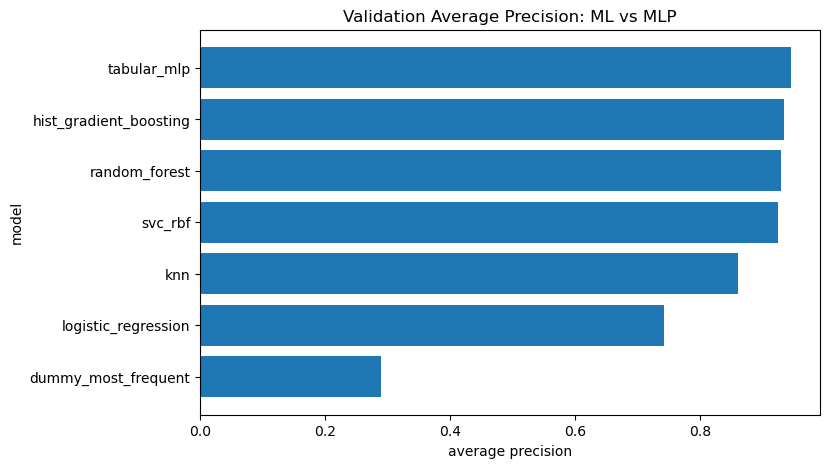

In [18]:
plt.figure(figsize=(8, 5))
plt.barh(all_val_df['model'], all_val_df['average_precision'])
plt.gca().invert_yaxis()
plt.title('Validation Average Precision: ML vs MLP')
plt.xlabel('average precision')
plt.ylabel('model')
plt.show()

## 10. 어떤 모델들을 1차 후보군으로 가져갈 것인가

validation `average_precision`을 기준으로
상위 성능 모델들을 1차 후보군으로 정리한다.

이 단계의 목적은 추가 튜닝과 threshold 조정, error analysis를 진행할 만한 모델을 좁히는 것이다.

validation 성능이 좋은 상위 2~4개 정도를 후보로 남긴 뒤, 하이퍼파라미터 조정과 threshold 비교를 추가로 진행한다.

즉, validation 단계의 결과는 최종 확정이라기보다
다음 실험으로 가져갈 후보를 좁히는 과정으로 이해하는 것이 더 적절하다.

In [19]:
# validation average precision 기준 상위 후보군을 선택한다.
top_k = 3
candidate_models = all_val_df.head(top_k)['model'].tolist()

print('validation 기준 1차 후보군:')
for i, model_name in enumerate(candidate_models, start=1):
    print(f'{i}. {model_name}')

validation 기준 1차 후보군:
1. tabular_mlp
2. hist_gradient_boosting
3. random_forest


In [20]:
# 후보군 결과만 따로 확인
candidate_val_df = all_val_df[all_val_df['model'].isin(candidate_models)].copy()
candidate_val_df = candidate_val_df.sort_values(by='average_precision', ascending=False).reset_index(drop=True)
candidate_val_df

,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,tabular_mlp,0.927917,0.860497,0.896403,0.878083,0.962087,0.944327
1,hist_gradient_boosting,0.927917,0.942373,0.800000,0.865370,0.960781,0.934100
2,random_forest,0.912083,0.954887,0.730935,0.828036,0.956238,0.928732


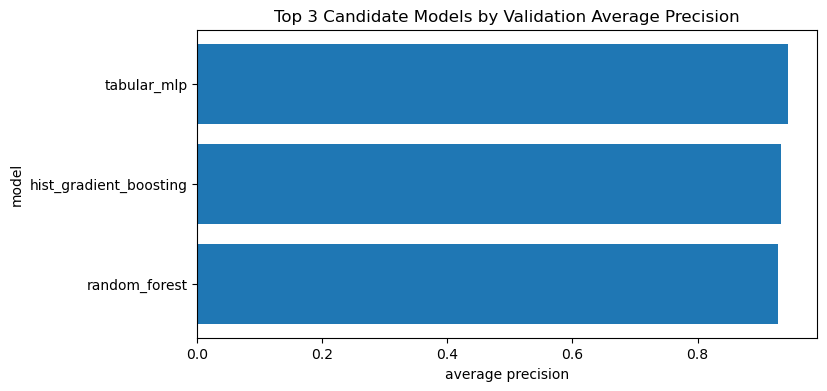

In [21]:
# 후보군 성능 시각화
plt.figure(figsize=(8, 4))
plt.barh(candidate_val_df['model'], candidate_val_df['average_precision'])
plt.gca().invert_yaxis()
plt.title(f'Top {top_k} Candidate Models by Validation Average Precision')
plt.xlabel('average precision')
plt.ylabel('model')
plt.show()

## 11. 후보군 안에서 무엇을 더 비교할 것인가

상위 3개 후보군은 average precision 기준으로 모두 강한 성능을 보였다.
하지만 최종 모델을 정할 때는 AP 하나만 볼 것이 아니라
precision, recall, F1, ROC-AUC도 함께 확인하는 것이 좋다.

## 12. 최종 모델은 validation 기준으로 결정

후보군 비교 결과 현재 validation 기준에서 최종 선택 모델로 두고 test 성능을 확인한다.

다만 실제 프로젝트에서는 여기서 바로 끝내지 않고, 후보군에 대해 threshold 조정이나 하이퍼파라미터 튜닝을 한 번 더 진행한 뒤 최종 모델을 확정할 수도 있다.

In [22]:
# 후보군 비교/튜닝을 마친 뒤 최종 선택한 모델 이름을 적는다.
final_model_name = candidate_models[0]

print('최종 선택 모델:', final_model_name)

최종 선택 모델: tabular_mlp


In [23]:
# 최종 선택 모델 객체와 타입 정리
if final_model_name == 'tabular_mlp':
    final_model = model   
    final_model_type = 'mlp'
else:
    final_model = ml_models[final_model_name]
    final_model_type = 'ml'

In [24]:
# 최종 선택한 모델 1개에 대해서만 test 평가를 수행한다.
if final_model_type == 'mlp':
    test_metrics, test_probs, test_preds = evaluate_mlp(final_model, test_loader, criterion)
else:
    test_metrics = evaluate_classifier(final_model, X_test, y_test)
    test_preds, test_probs = get_pred_and_score(final_model, X_test)

test_metrics

{'accuracy': 0.915,
 'precision': 0.8324324324324325,
 'recall': 0.8850574712643678,
 'f1': 0.8579387186629527,
 'roc_auc': 0.9480701257352545,
 'average_precision': 0.9161618774882758,
 'loss': 0.4128197801113129}

In [25]:
# confusion matrix 확인
cm = confusion_matrix(y_test, test_preds)

print('confusion matrix')
print(cm)

print()
print('classification report')
print(classification_report(y_test, test_preds, digits=4))

confusion matrix
[[1580  124]
 [  80  616]]

classification report
              precision    recall  f1-score   support

           0     0.9518    0.9272    0.9394      1704
           1     0.8324    0.8851    0.8579       696

    accuracy                         0.9150      2400
   macro avg     0.8921    0.9061    0.8986      2400
weighted avg     0.9172    0.9150    0.9157      2400



In [26]:
# 결과를 보기 좋게 정리
test_result_df = pd.DataFrame([{
    'selected_model': final_model_name,
    'accuracy': test_metrics['accuracy'],
    'precision': test_metrics['precision'],
    'recall': test_metrics['recall'],
    'f1': test_metrics['f1'],
    'roc_auc': test_metrics['roc_auc'],
    'average_precision': test_metrics['average_precision'],
}])

test_result_df

,selected_model,accuracy,precision,recall,f1,roc_auc,average_precision
0,tabular_mlp,0.915,0.832432,0.885057,0.857939,0.94807,0.916162


## 정리

1. baseline은 비교 기준이다.
2. train / validation / test 역할을 분리해야 한다.
3. 분류 문제에서는 accuracy만 보지 말고 데이터 특성에 맞는 지표를 같이 봐야 한다.
4. tabular 데이터에서는 전통적인 머신러닝 모델이 MLP보다 강할 수도 있다.
5. 모델 선택은 test가 아니라 validation 기준으로 먼저 해야 한다.